# Aproximação do seno com uma MLP

Este roteiro reproduz o experimento de criar amostras da função seno, treinar três redes neurais e comparar as funções aprendidas.

Na primeira execução, as três redes têm **exatamente a mesma configuração e a mesma semente aleatória**. Por isso, os três painéis começam iguais, representando um caso de **underfitting**.

Durante a aula, altere uma rede por vez e observe o efeito de:

- número de neurônios na camada oculta;
- taxa de aprendizagem;
- número máximo de épocas;
- meta de erro.

Arquitetura: `1 entrada → camada oculta (tanh) → 1 saída (tanh)`.

> A saída `tanh` foi mantida porque combina com o intervalo do seno, $[-1,1]$. Em aplicações gerais de regressão, é frequente usar saída linear.

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
COR_SENO = "#231971"
COR_MLP = "#00A878"
COR_TREINO = "#E63946"
COR_TESTE = "#4E79A7"

## 1. Conjuntos de treinamento e avaliação

O treinamento usa 26 valores de $x$ entre 0 e 10, com incremento de 0,4. Foi acrescentado um ruído muito pequeno aos alvos, apenas para representar observações não perfeitamente exatas sem esconder o formato do seno.

A grade de avaliação usa incremento de 0,02. Ela **não atualiza os pesos**: serve para desenhar a função aprendida entre os pontos de treinamento e, como conhecemos o seno verdadeiro, acompanhar o erro didaticamente.

In [ ]:
SEMENTE_DADOS = 12
DESVIO_RUIDO = 0.02  # quase zero em comparação com a amplitude do seno

rng_dados = np.random.default_rng(SEMENTE_DADOS)

x_treino = np.arange(0, 10.0001, 0.4).reshape(-1, 1)
y_seno_treino = np.sin(x_treino)
y_treino = y_seno_treino + rng_dados.normal(
    0, DESVIO_RUIDO, size=y_seno_treino.shape
)

x_avaliacao = np.arange(0, 10.0001, 0.02).reshape(-1, 1)
y_avaliacao = np.sin(x_avaliacao)

print(f"Amostras de treinamento: {len(x_treino)}")
print(f"Pontos da grade de avaliação: {len(x_avaliacao)}")

Amostras de treinamento: 26
Pontos da grade de avaliação: 501


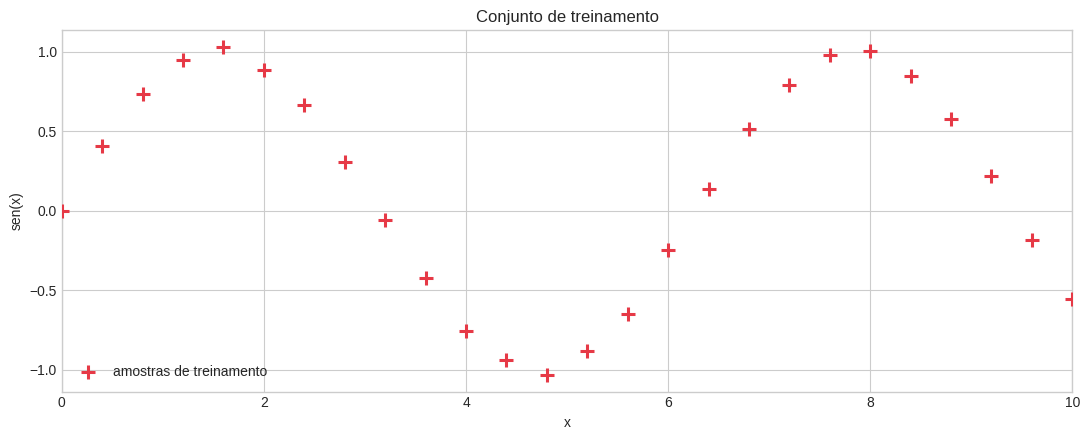

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
#ax.plot(
#    x_avaliacao, y_avaliacao,
#    color=COR_SENO, linewidth=2.2, alpha=0.55,
#    label="seno verdadeiro"
#)
ax.scatter(
    x_treino, y_treino,
    color=COR_TREINO, marker="+", s=95, linewidth=2.2,
    zorder=3, label="amostras de treinamento"
)
ax.set(
    title="Conjunto de treinamento",
    xlabel="x", ylabel="sen(x)", xlim=(0, 10)
)
ax.legend()
plt.tight_layout()
plt.show()

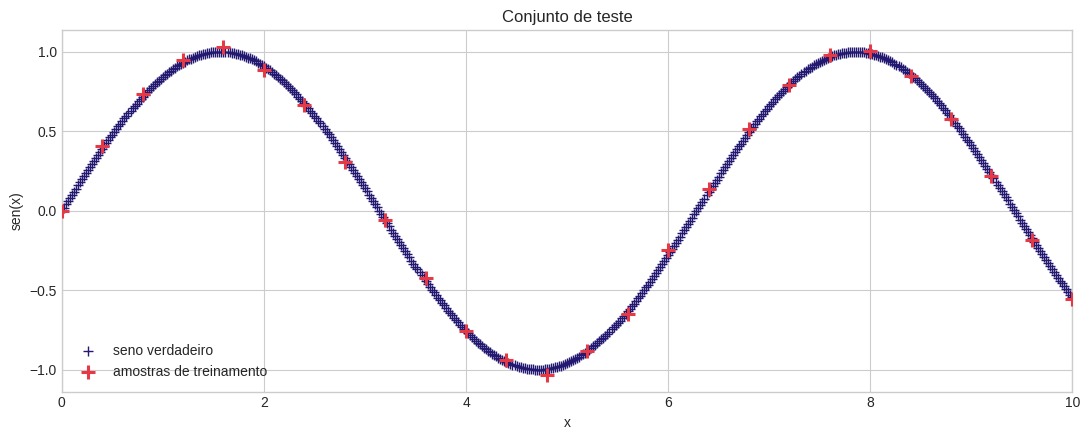

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(
    x_avaliacao, y_avaliacao,
    color=COR_SENO, marker="+", s=50, linewidth=1.0,
    label="seno verdadeiro"
)
ax.scatter(
    x_treino, y_treino,
    color=COR_TREINO, marker="+", s=95, linewidth=2.2,
    zorder=3, label="amostras de treinamento"
)
ax.set(
    title="Conjunto de teste",
    xlabel="x", ylabel="sen(x)", xlim=(0, 10)
)
ax.legend()
plt.tight_layout()
plt.show()

## 2. Preparação dos dados e funções da MLP

Os valores de entrada continuam sendo apresentados nos gráficos entre 0 e 10. Internamente, são reescalados para $[-1,1]$ para tornar o treinamento mais estável.

O código abaixo implementa a propagação, o erro quadrático médio e o backpropagation com descida do gradiente. Na experimentação, não é necessário alterar estas funções: as decisões da aula estarão reunidas no bloco de configurações.

In [ ]:
def normalizar_x(x):
    return 2 * (x / 10) - 1


X_treino = normalizar_x(x_treino)
X_avaliacao = normalizar_x(x_avaliacao)


def inicializar_rede(
    n_neuronios,
    semente,
    escala_inicializacao=5.0
):
    rng = np.random.default_rng(semente)

    inclinacoes = rng.uniform(
        1.0,
        escala_inicializacao,
        size=(1, n_neuronios)
    )
    inclinacoes *= rng.choice(
        [-1.0, 1.0],
        size=(1, n_neuronios)
    )

    centros = rng.uniform(
        -1.0, 1.0,
        size=(1, n_neuronios)
    )

    return {
        "W1": inclinacoes,
        "b1": -inclinacoes * centros,
        "W2": rng.normal(
            0, 0.05,
            size=(n_neuronios, 1)
        ),
        "b2": np.zeros((1, 1)),
    }

def propagar(X, parametros):
    z1 = X @ parametros["W1"] + parametros["b1"]
    a1 = np.tanh(z1)

    y_predito = a1 @ parametros["W2"] + parametros["b2"]
    return y_predito, a1


def mse(y_real, y_predito):
    return np.mean((y_real - y_predito) ** 2)

In [ ]:
def treinar_rede(configuracao, nome):
    parametros = inicializar_rede(
    configuracao["neuronios"],
    configuracao["semente"],
    configuracao.get("escala_inicializacao", 5.0)
)

    taxa = configuracao["taxa_aprendizado"]
    max_epocas = configuracao["epocas"]
    meta_erro = configuracao["meta_erro"]
    intervalo_registro = max(1, max_epocas // 500)
    n = len(X_treino)

    historico = {"epoca": [], "mse_treino": [], "mse_avaliacao": []}
    melhor_mse_avaliacao = np.inf
    melhor_epoca = 0
    melhores_parametros = copy.deepcopy(parametros)
    epoca_final = 0

    for epoca in range(max_epocas + 1):
        y_predito, a1 = propagar(X_treino, parametros)
        erro_treino = mse(y_treino, y_predito)

        deve_registrar = (
            epoca % intervalo_registro == 0
            or epoca == max_epocas
            or erro_treino <= meta_erro
        )

        if deve_registrar:
            y_grade, _ = propagar(X_avaliacao, parametros)
            erro_avaliacao = mse(y_avaliacao, y_grade)

            historico["epoca"].append(epoca)
            historico["mse_treino"].append(erro_treino)
            historico["mse_avaliacao"].append(erro_avaliacao)

            if erro_avaliacao < melhor_mse_avaliacao:
                melhor_mse_avaliacao = erro_avaliacao
                melhor_epoca = epoca
                melhores_parametros = copy.deepcopy(parametros)

        epoca_final = epoca
        if erro_treino <= meta_erro or epoca == max_epocas:
            break

        # Backpropagation: saída tanh + erro quadrático médio
        delta2 = (2 / n) * (y_predito - y_treino)
        grad_W2 = a1.T @ delta2
        grad_b2 = delta2.sum(axis=0, keepdims=True)

        delta1 = (delta2 @ parametros["W2"].T) * (1 - a1**2)
        grad_W1 = X_treino.T @ delta1
        grad_b1 = delta1.sum(axis=0, keepdims=True)

        parametros["W2"] -= taxa * grad_W2
        parametros["b2"] -= taxa * grad_b2
        parametros["W1"] -= taxa * grad_W1
        parametros["b1"] -= taxa * grad_b1

    y_grade_final, _ = propagar(X_avaliacao, parametros)
    y_treino_final, _ = propagar(X_treino, parametros)

    return {
        "nome": nome,
        "configuracao": configuracao.copy(),
        "parametros": parametros,
        "melhores_parametros": melhores_parametros,
        "predicao_grade": y_grade_final,
        "mse_treino_final": mse(y_treino, y_treino_final),
        "mse_avaliacao_final": mse(y_avaliacao, y_grade_final),
        "melhor_mse_avaliacao": melhor_mse_avaliacao,
        "melhor_epoca": melhor_epoca,
        "epoca_final": epoca_final,
        "historico": historico,
    }

## 3. Bloco de configuração — ponto de experimentação

As três redes começam iguais de propósito. Para comparar os efeitos dos hiperparâmetros:

1. preserve a Rede 1 como referência;
2. altere  `config_rede_2` e `config_rede_3` e execute novamente;

> Se duas redes tiverem os mesmos hiperparâmetros, mas sementes diferentes, elas poderão aprender curvas diferentes.

In [ ]:
config_rede_1 = {
    "neuronios": 2,
    "taxa_aprendizado": 0.10,
    "epocas": 1_000,
    "meta_erro": 0.05,
    "semente": 42,
    "escala_inicializacao": 5.0,
}

config_rede_2 = {
    "neuronios": 2,
    "taxa_aprendizado": 0.10,
    "epocas": 1_000,
    "meta_erro": 0.05,
    "semente": 42,
    "escala_inicializacao": 5.0,
}

config_rede_3 = {
    "neuronios": 2,
    "taxa_aprendizado": 0.10,
    "epocas": 1_000,
    "meta_erro": 0.05,
    "semente": 42,
    "escala_inicializacao": 5.0,
}


### Rede 1

In [ ]:
resultado_1 = treinar_rede(config_rede_1, "Rede 1")
print(
    f"Rede 1: {resultado_1['epoca_final']:,} épocas | "
    f"MSE treino = {resultado_1['mse_treino_final']:.5f} | "
    f"MSE avaliação = {resultado_1['mse_avaliacao_final']:.5f}"
)

Rede 1: 1,000 épocas | MSE treino = 0.13308 | MSE avaliação = 0.10259


### Rede 2

In [ ]:
resultado_2 = treinar_rede(config_rede_2, "Rede 2")
print(
    f"Rede 2: {resultado_2['epoca_final']:,} épocas | "
    f"MSE treino = {resultado_2['mse_treino_final']:.5f} | "
    f"MSE avaliação = {resultado_2['mse_avaliacao_final']:.5f}"
)

Rede 2: 1,000 épocas | MSE treino = 0.13308 | MSE avaliação = 0.10259


### Rede 3

In [ ]:
resultado_3 = treinar_rede(config_rede_3, "Rede 3")
print(
    f"Rede 3: {resultado_3['epoca_final']:,} épocas | "
    f"MSE treino = {resultado_3['mse_treino_final']:.5f} | "
    f"MSE avaliação = {resultado_3['mse_avaliacao_final']:.5f}"
)

Rede 3: 1,000 épocas | MSE treino = 0.13308 | MSE avaliação = 0.10259


## 4. Comparação tripla das funções aprendidas

Na primeira rodada, os três painéis estão iguais. Depois de cada experimento, execute novamente esta célula para atualizar a comparação.

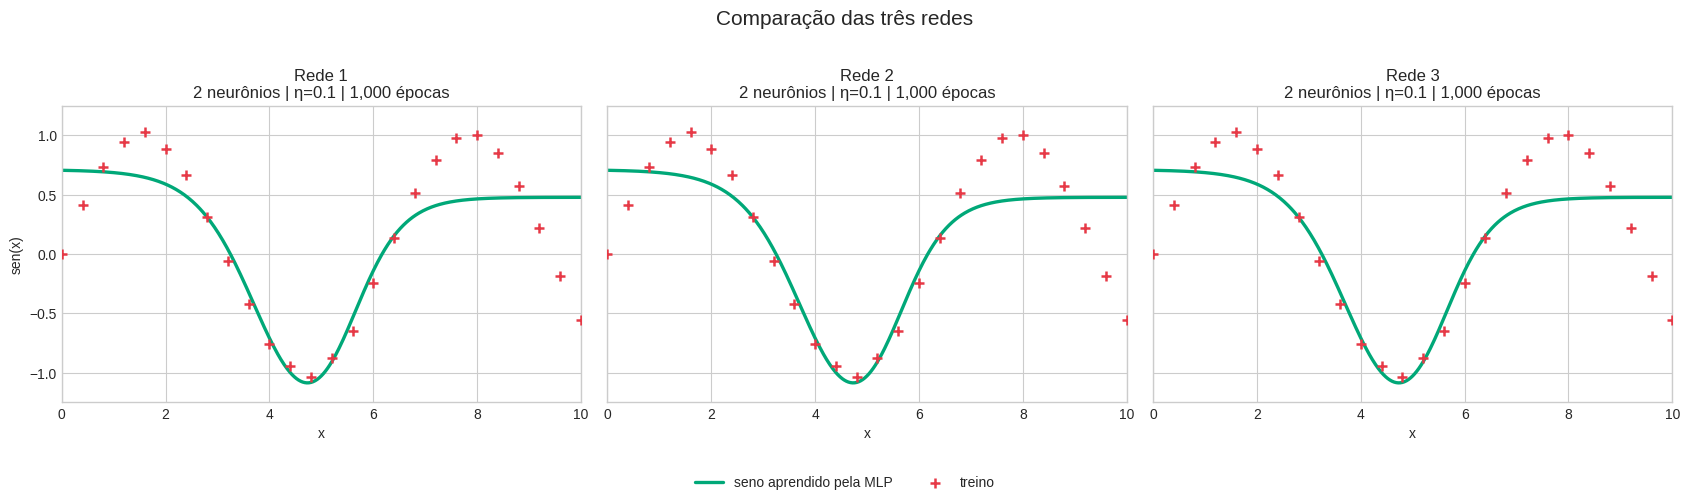

In [ ]:
resultados = [resultado_1, resultado_2, resultado_3]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharex=True, sharey=True)

for ax, resultado in zip(axes, resultados):
    cfg = resultado["configuracao"]
#    ax.plot(
#        x_avaliacao, y_avaliacao,
#        color=COR_SENO, linewidth=2.2, alpha=0.70,
#        label="seno verdadeiro"
#    )
    ax.plot(
        x_avaliacao, resultado["predicao_grade"],
        color=COR_MLP, linewidth=2.4,
        label="seno aprendido pela MLP"
    )
    ax.scatter(
        x_treino, y_treino,
        color=COR_TREINO, marker="+", s=60, linewidth=1.8,
        zorder=3, label="treino"
    )
    ax.set_title(
        f"{resultado['nome']}\n"
        f"{cfg['neuronios']} neurônios | "
        f"η={cfg['taxa_aprendizado']} | "
        f"{resultado['epoca_final']:,} épocas"
    )
    ax.set_xlabel("x")
    ax.set_xlim(0, 10)
    ax.set_ylim(-1.25, 1.25)

axes[0].set_ylabel("sen(x)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Comparação das três redes", fontsize=15, y=1.02)
plt.tight_layout(rect=(0, 0.09, 1, 1))
plt.show()

## 5. Curvas de aprendizagem e melhor época

Cada painel compara:

- o erro nos pontos usados para atualizar os pesos (conjunto de treinamento);
- o erro na grade densa que representa o seno verdadeiro (conjunto de teste);
- a época em que o erro da grade foi mínimo.

Procure três comportamentos:

- **underfitting:** os dois erros ainda são altos;
- **bom ajuste:** ambos atingem valores baixos e próximos;
- **overfitting:** o erro de treino continua diminuindo, mas o erro da grade passa a piorar.

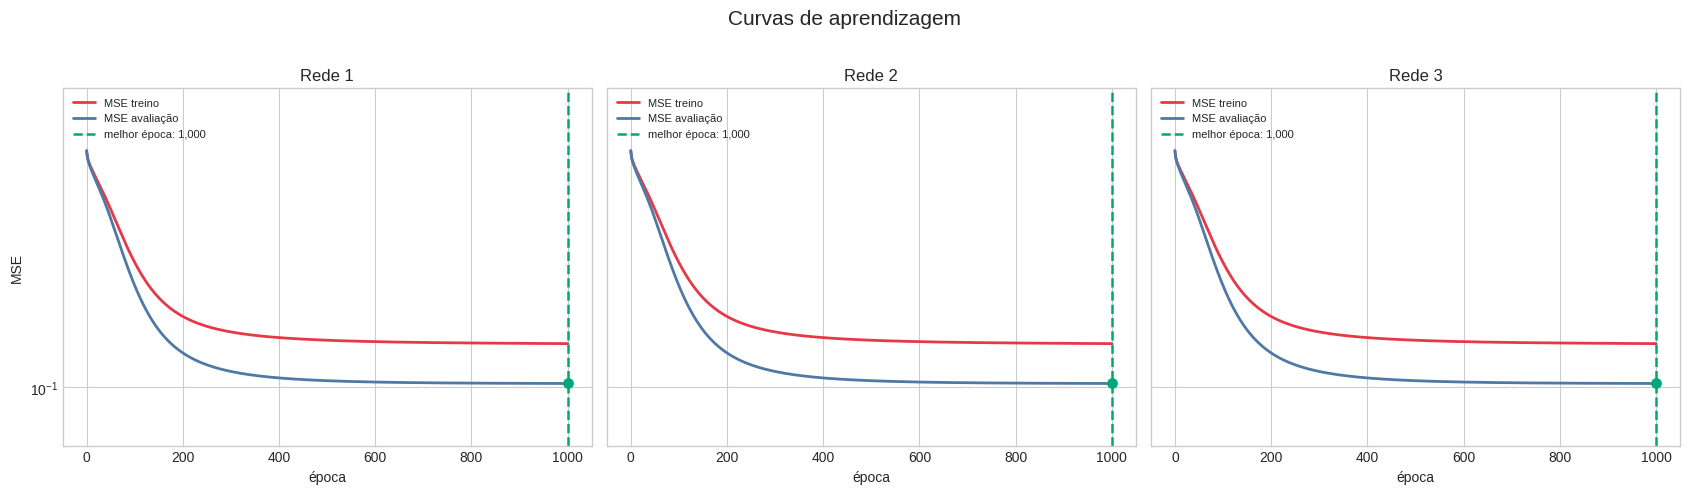

In [ ]:
# Calcula os limites considerando treino e avaliação das três redes
todos_mse = np.concatenate([
    np.asarray(resultado["historico"][tipo], dtype=float)
    for resultado in resultados
    for tipo in ["mse_treino", "mse_avaliacao"]
])

# A escala logarítmica aceita apenas valores positivos
todos_mse = todos_mse[
    np.isfinite(todos_mse) & (todos_mse > 0)
]

# Margem proporcional adequada à escala logarítmica
limite_inferior = todos_mse.min() / 1.5
limite_superior = todos_mse.max() * 1.5


fig, axes = plt.subplots(
    1, 3,
    figsize=(17, 4.8),
    sharey=True
)


for ax, resultado in zip(axes, resultados):
    h = resultado["historico"]

    ax.plot(
        h["epoca"], h["mse_treino"],
        color=COR_TREINO,
        linewidth=2.0,
        label="MSE treino"
    )

    ax.plot(
        h["epoca"], h["mse_avaliacao"],
        color=COR_TESTE,
        linewidth=2.0,
        label="MSE avaliação"
    )

    ax.axvline(
        resultado["melhor_epoca"],
        color=COR_MLP,
        linestyle="--",
        linewidth=1.8,
        label=f"melhor época: {resultado['melhor_epoca']:,}"
    )

    ax.scatter(
        [resultado["melhor_epoca"]],
        [resultado["melhor_mse_avaliacao"]],
        color=COR_MLP,
        s=45,
        zorder=3
    )

    ax.set_title(resultado["nome"])
    ax.set_xlabel("época")
    ax.set_yscale("log")
    ax.set_ylim(limite_inferior, limite_superior)
    ax.legend(fontsize=8)


axes[0].set_ylabel("MSE")

fig.suptitle(
    "Curvas de aprendizagem",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

## 6. Perguntas para orientar a experimentação

1. O que muda quando aumentamos apenas o número de neurônios?
2. Mais épocas sempre produzem uma função melhor?
3. Uma taxa de aprendizagem maior acelera o treinamento em qualquer situação?
4. O que acontece se a meta de erro for atingida antes do máximo de épocas?
5. Como distinguir overfitting de uma instabilidade causada por taxa de aprendizagem excessiva?
6. Se alterarmos somente a semente, o resultado será idêntico?

> **Ressalva metodológica:** em um problema real, não conheceríamos a função verdadeira. Usaríamos validação para acompanhar o treinamento e reservaríamos um conjunto de teste para a avaliação final. Aqui, a grade densa é uma referência didática porque sabemos que a função geradora é o seno.